## **K-Means Clustering**

### **Topic Roadmap**

**1. Load the original student-clustering dataset**

**2. Visualize the features**

**3. Select k with the elbow method**

**4. Fit and visualize K-Means**

**5. Key revision notes**

## **1.Dataset**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
students = pd.read_csv("docs/Lecture-094-student_clustering.csv")
X = students[["cgpa", "iq"]]
students.head()

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


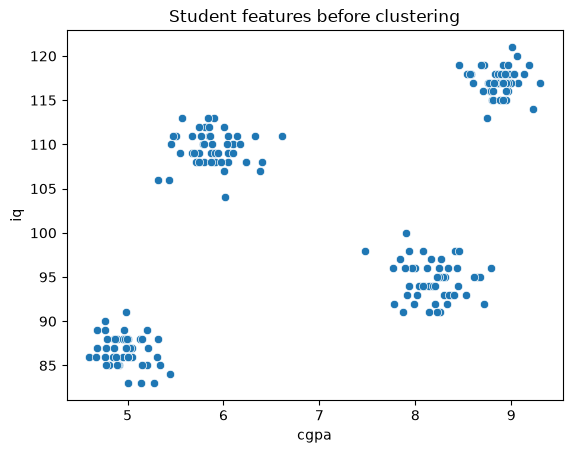

In [4]:
sns.scatterplot(data=students, x="cgpa", y="iq")
plt.title("Student features before clustering")
plt.show()

## **2. Choose the Number of Clusters**

The elbow method compares within-cluster sum of squares. The silhouette score adds a separation diagnostic.

In [5]:
inertias = []
silhouettes = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(X)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X, labels))
pd.DataFrame({"k": range(2, 9), "inertia": inertias, "silhouette": silhouettes})

,k,inertia,silhouette
0,2,4184.141270,0.754497
1,3,2364.005583,0.711275
2,4,681.969660,0.734968
3,5,514.161680,0.692229
4,6,398.403912,0.640915
5,7,302.547375,0.605181
6,8,233.540825,0.573486


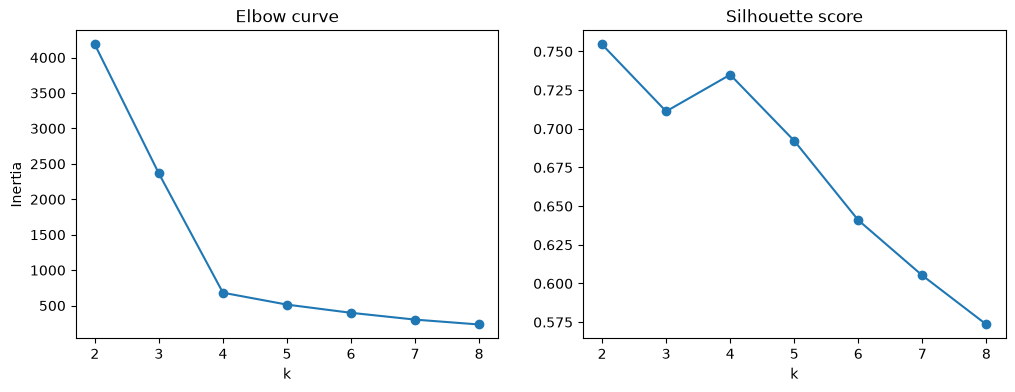

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(2, 9), inertias, marker="o")
axes[0].set_title("Elbow curve")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[1].plot(range(2, 9), silhouettes, marker="o")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
plt.show()

## **3. Fit the Final Model**

K-Means assigns each point to the nearest centroid and updates centroids until convergence.

In [7]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE)
students["cluster"] = kmeans.fit_predict(X)
print("Cluster sizes:")
print(students["cluster"].value_counts().sort_index())

Cluster sizes:
cluster
0    50
1    50
2    50
3    50
Name: count, dtype: int64


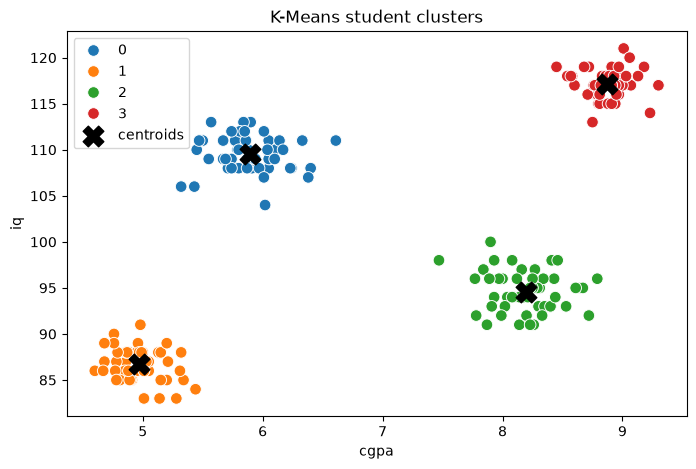

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=students, x="cgpa", y="iq", hue="cluster", palette="tab10", s=70)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker="X", s=220, c="black", label="centroids")
plt.title("K-Means student clusters")
plt.legend()
plt.show()

### **Key Revision Notes**

- K-Means minimizes the sum of squared distances to assigned centroids.
- `n_init` runs several centroid initializations and keeps the best inertia.
- Scaling matters when features use different units.
- Cluster labels are arbitrary identifiers, not ordered classes.